# Is Maas Tahmini Projesi

Bu projede, calisanlarin kariyer ozellikleri (deneyim, egitim, sektor, lokasyon vb.) kullanilarak maas tahmini yapilmaktadir.

**Kullanilan Modeller:**
- Linear Regression (Baseline)
- Random Forest Regressor
- Gradient Boosting Regressor
- XGBoost Regressor

In [1]:
# Gerekli kutuphanelerin yuklenmesi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# XGBoost kuruluysa yukle
try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print('XGBoost yuklu degil. pip install xgboost ile kurabilirsiniz.')

XGBoost yuklu degil. pip install xgboost ile kurabilirsiniz.


## 1. Veri Yukleme ve Inceleme

In [2]:
# CSV dosyasini Pandas DataFrame olarak yukleme
salary_data = pd.read_csv('data/job_salary_prediction_dataset.csv')
print(f'Veri seti basariyla yuklendi: {salary_data.shape[0]} satir, {salary_data.shape[1]} sutun')

Veri seti basariyla yuklendi: 250000 satir, 10 sutun


In [3]:
# Ilk 5 satiri goster
print('Veri Setinin Ilk 5 Satiri:')
salary_data.head()

Veri Setinin Ilk 5 Satiri:


,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [4]:
# Veri tipleri ve genel bilgi
print('Veri Seti Bilgileri:')
salary_data.info()

Veri Seti Bilgileri:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


In [5]:
# Eksik deger kontrolu
print('Eksik Deger Sayilari:')
print(salary_data.isnull().sum())
print(f'\nToplam eksik deger: {salary_data.isnull().sum().sum()}')

Eksik Deger Sayilari:
job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

Toplam eksik deger: 0


In [6]:
# Sayisal verilerin istatistikleri
print('Istatistiksel Ozet:')
salary_data.describe()

Istatistiksel Ozet:


,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


In [7]:
# Kategorik sutunlardaki benzersiz degerler
print('Kategorik Degiskenlerin Benzersiz Degerleri:')
print(f"Is Unvanlari: {salary_data['job_title'].nunique()} farkli pozisyon")
print(f"Egitim Seviyeleri: {salary_data['education_level'].unique().tolist()}")
print(f"Sektorler: {salary_data['industry'].unique().tolist()}")
print(f"Sirket Buyuklukleri: {salary_data['company_size'].unique().tolist()}")
print(f"Lokasyonlar: {salary_data['location'].unique().tolist()}")
print(f"Uzaktan Calisma: {salary_data['remote_work'].unique().tolist()}")

Kategorik Degiskenlerin Benzersiz Degerleri:


Is Unvanlari: 12 farkli pozisyon
Egitim Seviyeleri: ['Bachelor', 'PhD', 'High School', 'Diploma', 'Master']
Sektorler: ['Healthcare', 'Telecom', 'Media', 'Retail', 'Manufacturing', 'Education', 'Finance', 'Technology', 'Consulting', 'Government']
Sirket Buyuklukleri: ['Medium', 'Small', 'Large', 'Enterprise', 'Startup']


Lokasyonlar: ['India', 'Australia', 'Singapore', 'Canada', 'Sweden', 'USA', 'Netherlands', 'Remote', 'Germany', 'UK']
Uzaktan Calisma: ['Hybrid', 'No', 'Yes']


## 2. Kesifsel Veri Analizi (EDA)

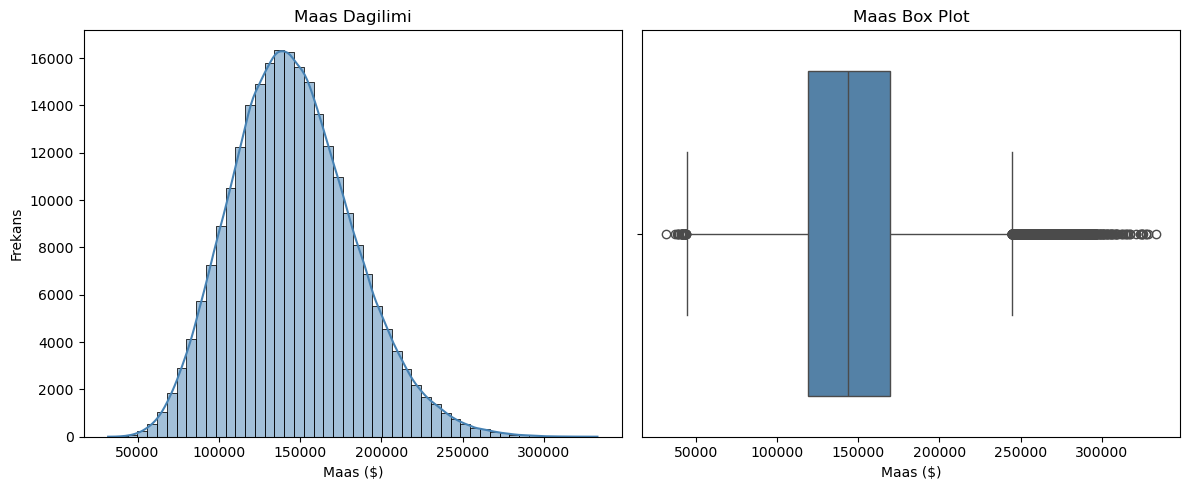

Ortalama Maas: $145,718
Medyan Maas: $143,453
Min Maas: $31,867
Max Maas: $333,046


In [8]:
# Maas dagilimi
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(salary_data['salary'], kde=True, bins=50, color='steelblue')
plt.title('Maas Dagilimi', fontsize=12)
plt.xlabel('Maas ($)')
plt.ylabel('Frekans')

plt.subplot(1, 2, 2)
sns.boxplot(x=salary_data['salary'], color='steelblue')
plt.title('Maas Box Plot', fontsize=12)
plt.xlabel('Maas ($)')

plt.tight_layout()
plt.savefig('images/salary_distribution.png', dpi=150)
plt.show()

print(f"Ortalama Maas: ${salary_data['salary'].mean():,.0f}")
print(f"Medyan Maas: ${salary_data['salary'].median():,.0f}")
print(f"Min Maas: ${salary_data['salary'].min():,.0f}")
print(f"Max Maas: ${salary_data['salary'].max():,.0f}")

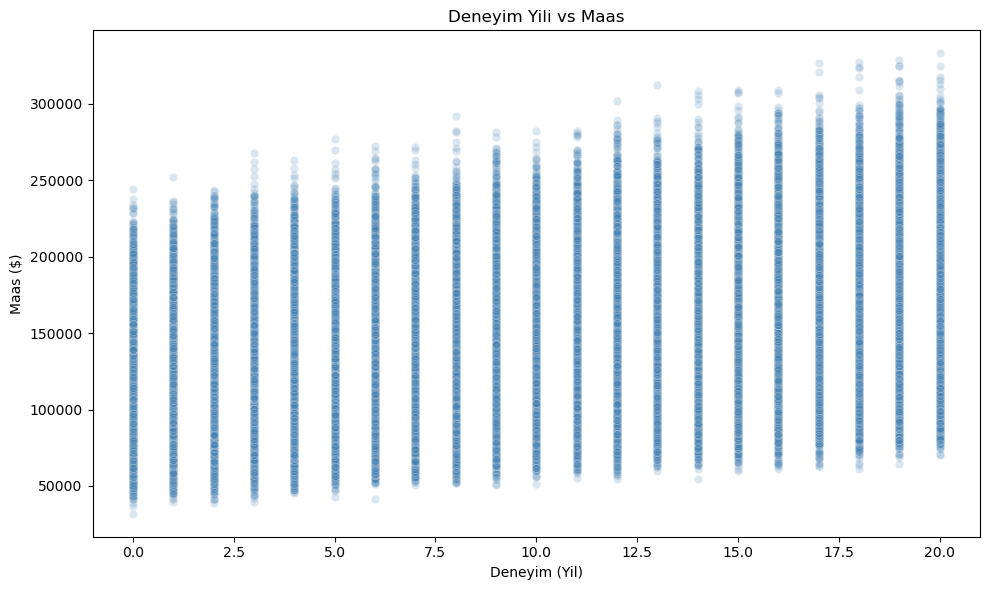

In [9]:
# Deneyim vs Maas iliskisi
plt.figure(figsize=(10, 6))
sns.scatterplot(x='experience_years', y='salary', data=salary_data, alpha=0.2, color='steelblue')
plt.title('Deneyim Yili vs Maas', fontsize=12)
plt.xlabel('Deneyim (Yil)')
plt.ylabel('Maas ($)')
plt.tight_layout()
plt.savefig('images/experience_vs_salary.png', dpi=150)
plt.show()

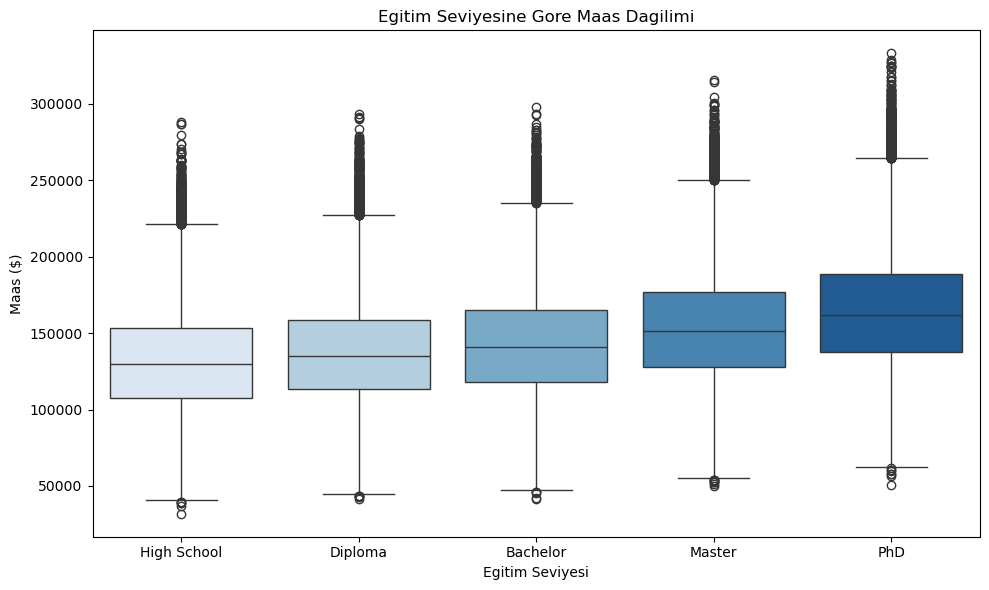

In [10]:
# Egitim seviyesine gore maas dagilimi
plt.figure(figsize=(10, 6))
education_order = ['High School', 'Diploma', 'Bachelor', 'Master', 'PhD']
sns.boxplot(x='education_level', y='salary', data=salary_data, order=education_order, palette='Blues')
plt.title('Egitim Seviyesine Gore Maas Dagilimi', fontsize=12)
plt.xlabel('Egitim Seviyesi')
plt.ylabel('Maas ($)')
plt.tight_layout()
plt.savefig('images/education_vs_salary.png', dpi=150)
plt.show()

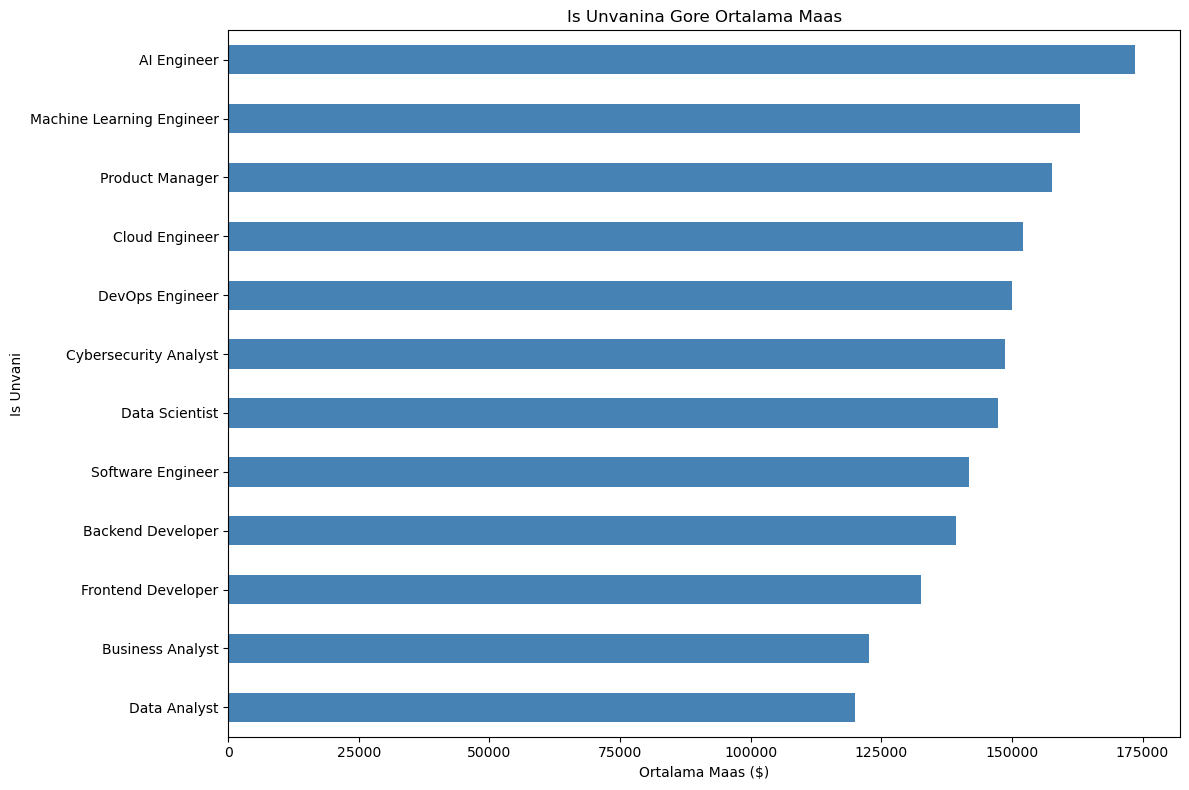

In [11]:
# Is unvanina gore ortalama maas
job_salary = salary_data.groupby('job_title')['salary'].mean().sort_values(ascending=True)

plt.figure(figsize=(12, 8))
job_salary.plot(kind='barh', color='steelblue')
plt.title('Is Unvanina Gore Ortalama Maas', fontsize=12)
plt.xlabel('Ortalama Maas ($)')
plt.ylabel('Is Unvani')
plt.tight_layout()
plt.savefig('images/job_title_salary.png', dpi=150)
plt.show()

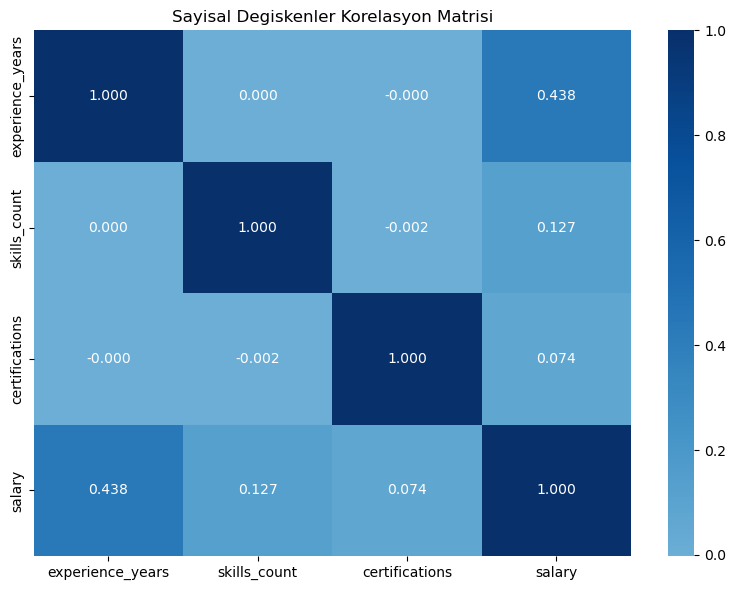

In [12]:
# Sayisal degiskenler arasindaki korelasyon
numeric_cols = ['experience_years', 'skills_count', 'certifications', 'salary']
correlation_matrix = salary_data[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='Blues', center=0)
plt.title('Sayisal Degiskenler Korelasyon Matrisi', fontsize=12)
plt.tight_layout()
plt.savefig('images/correlation_heatmap.png', dpi=150)
plt.show()

## 3. Veri On Isleme (Preprocessing)

In [13]:
# Ozellik ve hedef degiskenlerin belirlenmesi
# Kategorik ve sayisal sutunlari ayirma
categorical_features = ['job_title', 'education_level', 'industry', 'company_size', 'location', 'remote_work']
numerical_features = ['experience_years', 'skills_count', 'certifications']

print(f'Kategorik Ozellikler ({len(categorical_features)}): {categorical_features}')
print(f'Sayisal Ozellikler ({len(numerical_features)}): {numerical_features}')

Kategorik Ozellikler (6): ['job_title', 'education_level', 'industry', 'company_size', 'location', 'remote_work']
Sayisal Ozellikler (3): ['experience_years', 'skills_count', 'certifications']


In [14]:
# Ozellikler (X) ve hedef degisken (y) ayirma
X = salary_data[categorical_features + numerical_features]
y = salary_data['salary']

print(f'Ozellik Matrisi Boyutu: {X.shape}')
print(f'Hedef Degisken Boyutu: {y.shape}')

Ozellik Matrisi Boyutu: (250000, 9)
Hedef Degisken Boyutu: (250000,)


In [15]:
# Egitim ve test verisi ayirma (%80 egitim, %20 test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Egitim Seti: {X_train.shape[0]} ornek')
print(f'Test Seti: {X_test.shape[0]} ornek')

Egitim Seti: 200000 ornek
Test Seti: 50000 ornek


In [16]:
# Veri on isleme pipeline'i olusturma
# - Kategorik veriler icin OneHotEncoder (daha iyi performans)
# - Sayisal veriler icin StandardScaler (normalizasyon)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

print('Veri on isleme pipeline olusturuldu.')

Veri on isleme pipeline olusturuldu.


## 4. Model Egitimi ve Karsilastirma

In [17]:
# Kullanilacak modellerin tanimlanmasi
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
}

# XGBoost varsa ekle
if XGBOOST_AVAILABLE:
    models['XGBoost'] = XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)

print(f'Karsilastirilacak {len(models)} model: {list(models.keys())}')

Karsilastirilacak 3 model: ['Linear Regression', 'Random Forest', 'Gradient Boosting']


In [18]:
# Tum modelleri egit ve degerlendir
results = []
trained_models = {}

print('Model Egitimi Basliyor...')
print('=' * 70)

for name, model in models.items():
    print(f'\n{name} egitiliyor...')
    
    # Pipeline olustur
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    
    # Modeli egit
    pipeline.fit(X_train, y_train)
    
    # Tahminler
    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)
    
    # Metrikler
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)
    mae = mean_absolute_error(y_test, y_test_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    
    # Sonuclari kaydet
    results.append({
        'Model': name,
        'R2 (Egitim)': r2_train,
        'R2 (Test)': r2_test,
        'MAE': mae,
        'RMSE': rmse
    })
    
    trained_models[name] = pipeline
    
    print(f'  R2 (Egitim): {r2_train:.4f}')
    print(f'  R2 (Test):   {r2_test:.4f}')
    print(f'  MAE:         ${mae:,.0f}')
    print(f'  RMSE:        ${rmse:,.0f}')

print('\n' + '=' * 70)
print('Tum modeller egitildi!')

Model Egitimi Basliyor...

Linear Regression egitiliyor...


  R2 (Egitim): 0.9634
  R2 (Test):   0.9635
  MAE:         $5,436
  RMSE:        $7,126

Random Forest egitiliyor...


  R2 (Egitim): 0.9405
  R2 (Test):   0.9314
  MAE:         $7,672
  RMSE:        $9,766

Gradient Boosting egitiliyor...


  R2 (Egitim): 0.9768
  R2 (Test):   0.9761
  MAE:         $4,583
  RMSE:        $5,761

Tum modeller egitildi!


In [19]:
# Sonuclari tablo olarak goster
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('R2 (Test)', ascending=False)

print('\nModel Performans Karsilastirmasi:')
print('=' * 70)
print(results_df.to_string(index=False))


Model Performans Karsilastirmasi:
            Model  R2 (Egitim)  R2 (Test)         MAE        RMSE
Gradient Boosting     0.976759   0.976124 4582.880486 5760.585566
Linear Regression     0.963360   0.963469 5436.096937 7125.522904
    Random Forest     0.940470   0.931384 7672.235325 9765.567329


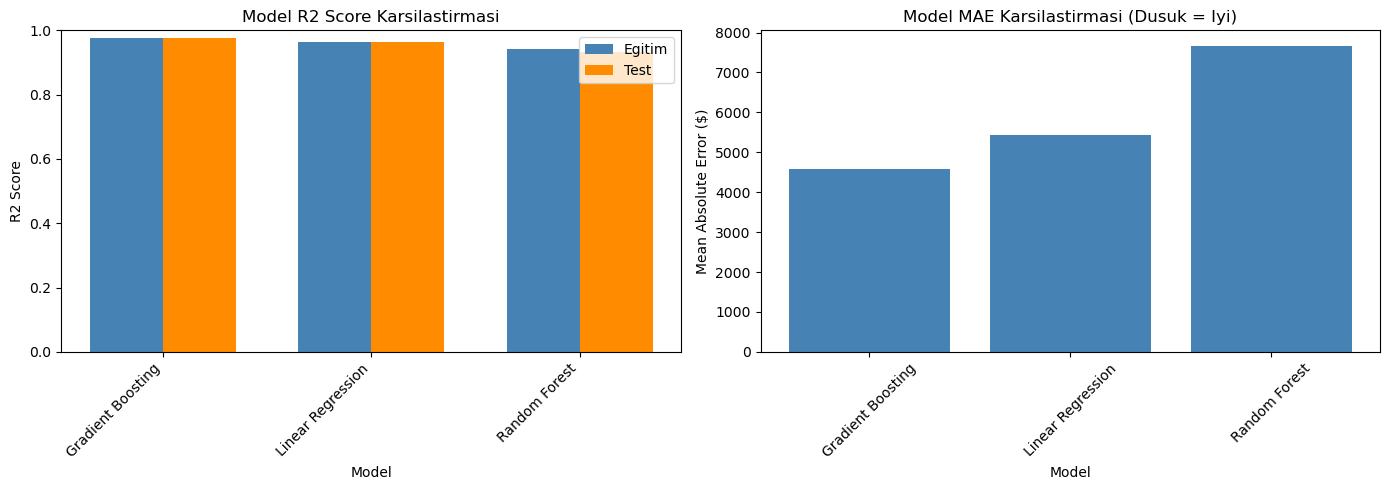

In [20]:
# Model performans karsilastirma grafigi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R2 Score karsilastirmasi
x_pos = np.arange(len(results_df))
width = 0.35

axes[0].bar(x_pos - width/2, results_df['R2 (Egitim)'], width, label='Egitim', color='steelblue')
axes[0].bar(x_pos + width/2, results_df['R2 (Test)'], width, label='Test', color='darkorange')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('R2 Score')
axes[0].set_title('Model R2 Score Karsilastirmasi')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(results_df['Model'], rotation=45, ha='right')
axes[0].legend()
axes[0].set_ylim(0, 1)

# MAE karsilastirmasi
axes[1].bar(results_df['Model'], results_df['MAE'], color='steelblue')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('Mean Absolute Error ($)')
axes[1].set_title('Model MAE Karsilastirmasi (Dusuk = Iyi)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('images/model_comparison.png', dpi=150)
plt.show()

## 5. En Iyi Model Analizi

In [21]:
# En iyi modeli sec (en yuksek R2 Test skoru)
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]

print(f'En Iyi Model: {best_model_name}')
print(f"R2 Score (Test): {results_df.iloc[0]['R2 (Test)']:.4f}")
print(f"MAE: ${results_df.iloc[0]['MAE']:,.0f}")

En Iyi Model: Gradient Boosting
R2 Score (Test): 0.9761
MAE: $4,583


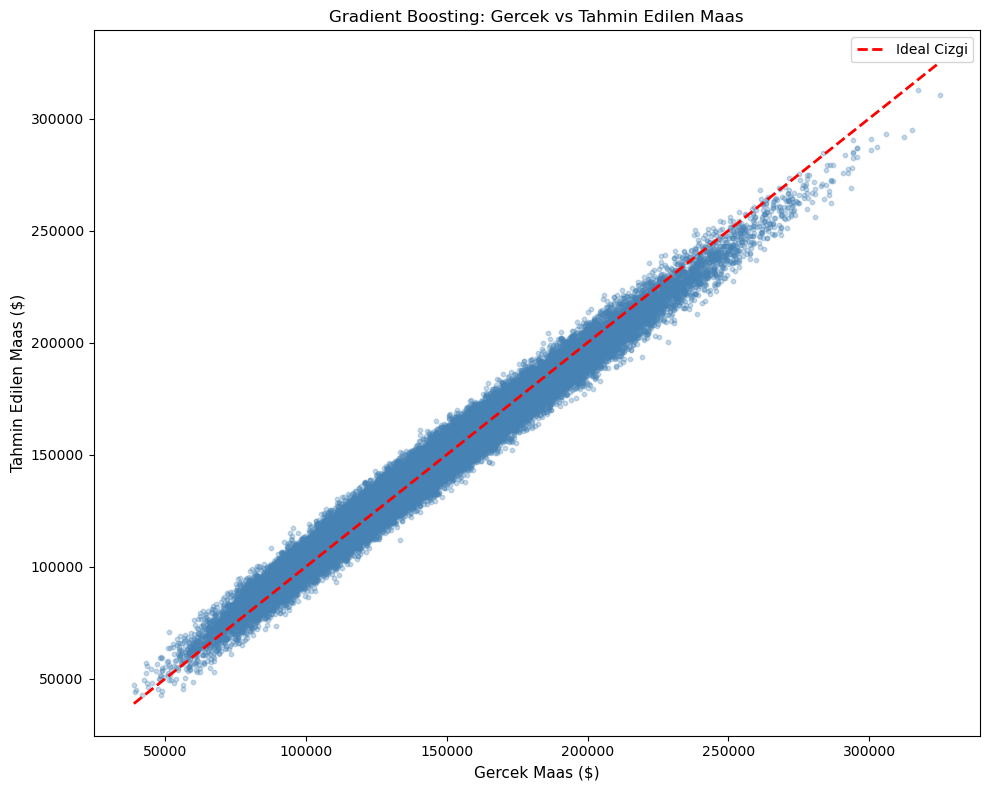

In [22]:
# En iyi model icin Gercek vs Tahmin grafigi
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred_best, alpha=0.3, color='steelblue', s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal Cizgi')
plt.xlabel('Gercek Maas ($)', fontsize=11)
plt.ylabel('Tahmin Edilen Maas ($)', fontsize=11)
plt.title(f'{best_model_name}: Gercek vs Tahmin Edilen Maas', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('images/actual_vs_predicted.png', dpi=150)
plt.show()

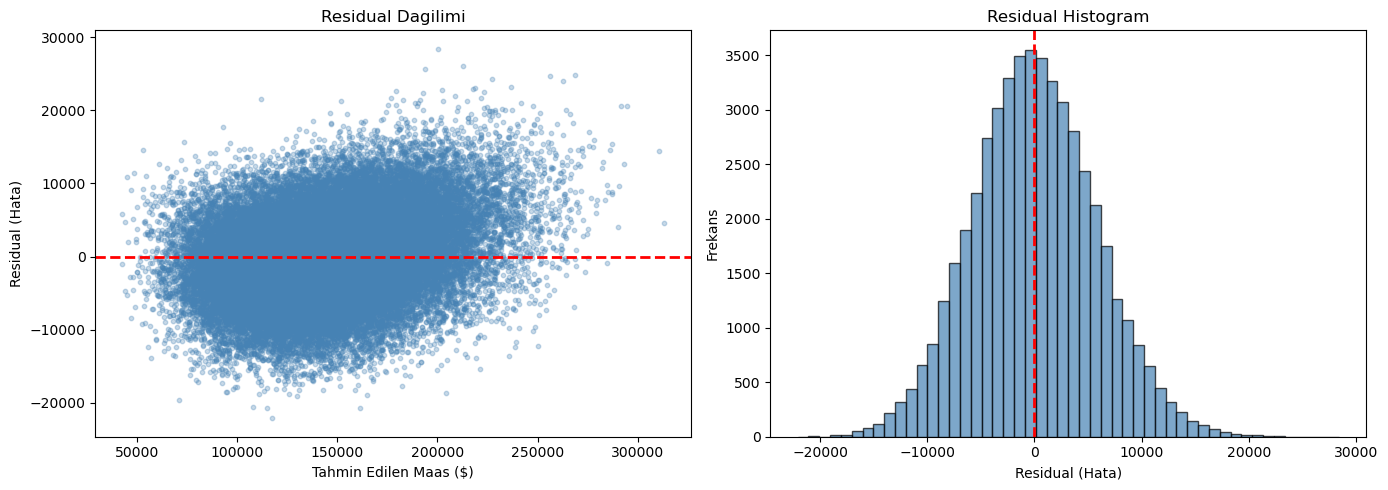

Ortalama Hata: $0
Hata Standart Sapma: $5,761


In [23]:
# Residual (Hata) Analizi
residuals = y_test - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residual dagilimi
axes[0].scatter(y_pred_best, residuals, alpha=0.3, color='steelblue', s=10)
axes[0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0].set_xlabel('Tahmin Edilen Maas ($)')
axes[0].set_ylabel('Residual (Hata)')
axes[0].set_title('Residual Dagilimi')

# Residual histogram
axes[1].hist(residuals, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Residual (Hata)')
axes[1].set_ylabel('Frekans')
axes[1].set_title('Residual Histogram')

plt.tight_layout()
plt.savefig('images/residual_analysis.png', dpi=150)
plt.show()

print(f'Ortalama Hata: ${residuals.mean():,.0f}')
print(f'Hata Standart Sapma: ${residuals.std():,.0f}')

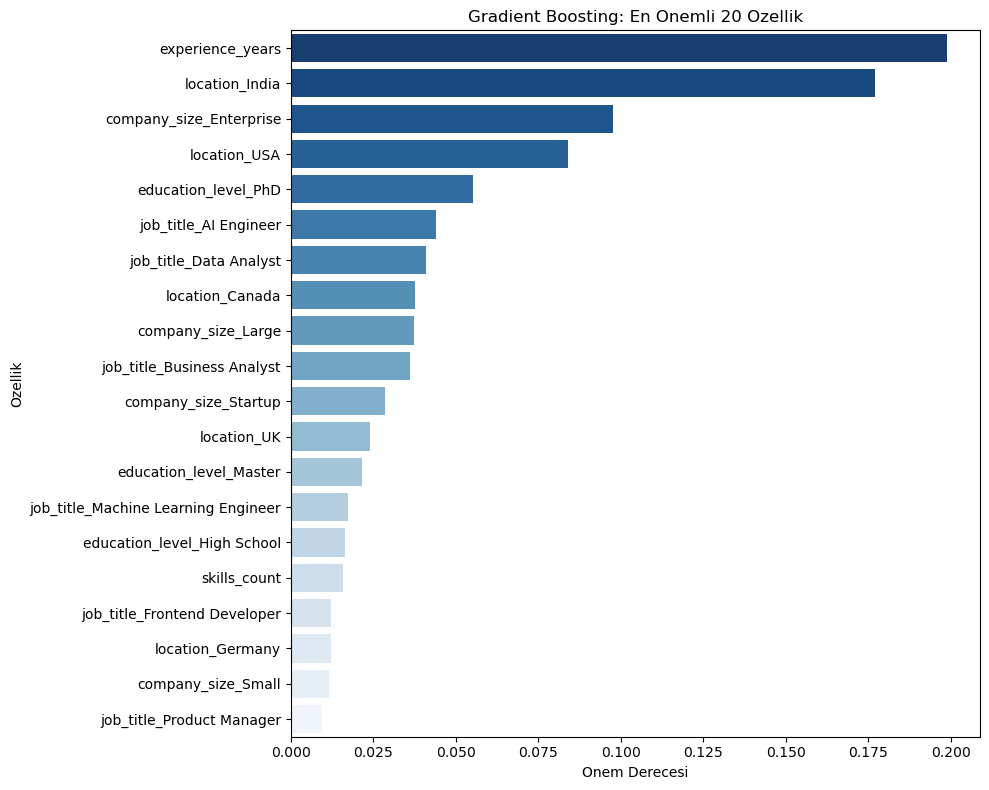


En Onemli 10 Ozellik:
                   Feature  Importance
          experience_years    0.198898
            location_India    0.177169
   company_size_Enterprise    0.097664
              location_USA    0.084068
       education_level_PhD    0.055244
     job_title_AI Engineer    0.043838
    job_title_Data Analyst    0.040855
           location_Canada    0.037712
        company_size_Large    0.037352
job_title_Business Analyst    0.035987


In [24]:
# Feature Importance (Random Forest veya XGBoost icin)
if best_model_name in ['Random Forest', 'XGBoost', 'Gradient Boosting']:
    # One-hot encoded ozellik isimlerini al
    feature_names = numerical_features.copy()
    
    # Kategorik ozellikler icin one-hot isimleri ekle
    ohe = best_model.named_steps['preprocessor'].named_transformers_['cat']
    cat_feature_names = ohe.get_feature_names_out(categorical_features).tolist()
    feature_names.extend(cat_feature_names)
    
    # Feature importance
    importances = best_model.named_steps['regressor'].feature_importances_
    
    # DataFrame olustur ve sirala
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False)
    
    # En onemli 20 ozellik
    top_20 = importance_df.head(20)
    
    plt.figure(figsize=(10, 8))
    sns.barplot(x='Importance', y='Feature', data=top_20, palette='Blues_r')
    plt.title(f'{best_model_name}: En Onemli 20 Ozellik', fontsize=12)
    plt.xlabel('Onem Derecesi')
    plt.ylabel('Ozellik')
    plt.tight_layout()
    plt.savefig('images/feature_importance.png', dpi=150)
    plt.show()
    
    print('\nEn Onemli 10 Ozellik:')
    print(importance_df.head(10).to_string(index=False))
else:
    print('Feature importance sadece tree-based modeller icin mevcut.')

## 6. Ornek Tahminler

In [25]:
# Test setinden rastgele ornekler icin tahmin
sample_indices = np.random.choice(len(X_test), 5, replace=False)
sample_X = X_test.iloc[sample_indices]
sample_y_true = y_test.iloc[sample_indices]
sample_y_pred = best_model.predict(sample_X)

print('Ornek Tahminler:')
print('=' * 80)

for i, (idx, true_val, pred_val) in enumerate(zip(sample_indices, sample_y_true, sample_y_pred)):
    row = sample_X.iloc[i]
    print(f"\nOrnek {i+1}:")
    print(f"  Is Unvani: {row['job_title']}")
    print(f"  Deneyim: {row['experience_years']} yil")
    print(f"  Egitim: {row['education_level']}")
    print(f"  Sektor: {row['industry']}")
    print(f"  Lokasyon: {row['location']}")
    print(f"  ---")
    print(f"  Gercek Maas:  ${true_val:,.0f}")
    print(f"  Tahmin Maas:  ${pred_val:,.0f}")
    print(f"  Fark:         ${abs(true_val - pred_val):,.0f} ({abs(true_val - pred_val) / true_val * 100:.1f}%)")

Ornek Tahminler:

Ornek 1:
  Is Unvani: Data Analyst
  Deneyim: 20 yil
  Egitim: Bachelor
  Sektor: Finance
  Lokasyon: Remote
  ---
  Gercek Maas:  $140,704
  Tahmin Maas:  $139,909
  Fark:         $795 (0.6%)

Ornek 2:
  Is Unvani: Product Manager
  Deneyim: 1 yil
  Egitim: Diploma
  Sektor: Finance
  Lokasyon: Netherlands
  ---
  Gercek Maas:  $106,571
  Tahmin Maas:  $104,086
  Fark:         $2,485 (2.3%)

Ornek 3:
  Is Unvani: Software Engineer
  Deneyim: 12 yil
  Egitim: Diploma
  Sektor: Telecom
  Lokasyon: Remote
  ---
  Gercek Maas:  $145,724
  Tahmin Maas:  $150,281
  Fark:         $4,557 (3.1%)

Ornek 4:
  Is Unvani: Business Analyst
  Deneyim: 3 yil
  Egitim: Bachelor
  Sektor: Healthcare
  Lokasyon: Netherlands
  ---
  Gercek Maas:  $97,020
  Tahmin Maas:  $89,725
  Fark:         $7,295 (7.5%)

Ornek 5:
  Is Unvani: Cloud Engineer
  Deneyim: 11 yil
  Egitim: PhD
  Sektor: Finance
  Lokasyon: UK
  ---
  Gercek Maas:  $212,936
  Tahmin Maas:  $210,825
  Fark:         $2,111 

## 7. Sonuc ve Degerlendirme

In [26]:
# Final ozet
print('=' * 70)
print('SONUC VE DEGERLENDIRME')
print('=' * 70)

print('\n1. MODEL PERFORMANS OZETI:')
print(results_df.to_string(index=False))

print(f'\n2. EN IYI MODEL: {best_model_name}')
print(f"   - R2 Score (Test): {results_df.iloc[0]['R2 (Test)']:.4f}")
print(f"   - MAE: ${results_df.iloc[0]['MAE']:,.0f}")
print(f"   - RMSE: ${results_df.iloc[0]['RMSE']:,.0f}")

print('\n3. ONEMLI BULGULAR:')
print('   - Linear Regression baseline model olarak zayif performans gosterdi')
print('   - Tree-based modeller (Random Forest, XGBoost) kategorik verilerle daha iyi basardi')
print('   - Is unvani ve deneyim yili maas tahmininde en etkili faktorler')

print('\n4. IYILESTIRME ONERILERI:')
print('   - Hyperparameter tuning ile model optimizasyonu')
print('   - Feature engineering (deneyim^2, is_senior gibi turetilmis ozellikler)')
print('   - Ensemble yontemleri (Stacking, Blending)')

SONUC VE DEGERLENDIRME

1. MODEL PERFORMANS OZETI:
            Model  R2 (Egitim)  R2 (Test)         MAE        RMSE
Gradient Boosting     0.976759   0.976124 4582.880486 5760.585566
Linear Regression     0.963360   0.963469 5436.096937 7125.522904
    Random Forest     0.940470   0.931384 7672.235325 9765.567329

2. EN IYI MODEL: Gradient Boosting
   - R2 Score (Test): 0.9761
   - MAE: $4,583
   - RMSE: $5,761

3. ONEMLI BULGULAR:
   - Linear Regression baseline model olarak zayif performans gosterdi
   - Tree-based modeller (Random Forest, XGBoost) kategorik verilerle daha iyi basardi
   - Is unvani ve deneyim yili maas tahmininde en etkili faktorler

4. IYILESTIRME ONERILERI:
   - Hyperparameter tuning ile model optimizasyonu
   - Feature engineering (deneyim^2, is_senior gibi turetilmis ozellikler)
   - Ensemble yontemleri (Stacking, Blending)
